In [1]:
# This cell is tagged for removal

import os
from glob import glob

import aliases # important this goes first to configure PATH
from everest.window import image, imop

## Defining a cylindrical geometry

In any convection model, gravity defines the natural 'down' direction and gives us our first most important scale: the depth $z$ from the surface, or its complement, the height from the model base $h=1-z$.

If the domain is allowed to curve around a certain locus, a cylindrical or annular geometry is obtained which is more appropriate for planetary mantles. While we retain $h$ and $z$ as terms relevant to any action within the domain, we must also introduce a concept of radial height $r$, understood here to represent the distance from the planetary centre of gravity. The cylindrical domain, for us representing the mantle, is thus bounded by the inner radius $r_{i}$ and the outer radius $r_{o}$, defining an area of $\pi(r_o^2 - r_i^2)$.

Our choice of radii implies a degree of curvature $f$:

$$ f \equiv \frac{r_o}{r_i} $$

Where $f\to1$ is equivalent to an infinitely wide Cartesian box, $f\to0$ represents a complete disc (i.e. no hole in the middle), and the values $\sim 0.5$ and $\sim 0.9$ would be appropriate for the whole mantle and upper mantle respectively. The ratio of radii $f$ is identical to the ratio of circumferences, so that $f=0.5$ represents a system where the arc length of the base is half that of the surface. (Note that this would imply infinite planetary radius at $f=1$ - hence the planar-like endmember $f=1$ is not strictly reachable under an assumption of curvature, though arbitrarily high values can be set to reproduce that behaviour [@Jarvis1993-cb])

If we further stipulate that the radial thickness of the domain is restricted to unit:

$$
\Delta r = r_{o} - r_{i} = 1
$$

$$
r_{o} \to 1 \quad \mathrm{as} \quad f \to 0
$$

Then:

$$
r_i = \frac{f}{1 - f}, \quad r_o = \frac{1}{1 - f}
$$

$$
r(h) = r_i + h
$$

In short: honouring this constraint allows us to produce a workable radial coordinate system simply by setting a desired value of $f$.

At other times, it may be convenient to set the radius at the outer boundary as unit, and relax the constraint for the mantle thickness to be unit. This has the effect of scaling the inner radius so that it is exactly $f$. We will call this metric the 'planetary radial scale' ${r^*}$:

$$
{{r^*}}_i = f, \quad {{r^*}}_o = 1
$$

$$
\Delta {r^*} = 1 - f
$$

$$
{r^*}(h) = \frac{h + r_i}{r_0} = \frac{\Delta {{r^*}}}{r} = h(1-f) + f
$$

(Note that ${r^*}$ and $r$ converge as $f$ approaches zero.)

This leaves us with four different terms to describe radial position: $h$, the dimensionless height from the mantle base; $z$, its complement; $r$, the radial scale such that the thickness of the mantle is one; and ${r^*}$, the radial scale such that the total planetary radius is one. Each of these scales will prove natural in some contexts and less so in others, and all find use in our analysis.

We have our radial coordinate system: now we need a system for our angular position too. The obvious way to do this is by simply providing an angle $\theta$ in radians anticlockwise from an arbitrary origin - i.e. $0 \le \theta < 2\pi$. In practice, we will often want to work with only a small wedge of the planet at any given time. This is equivalent to choosing a maximum value, $\Theta$:

$$ 0 \le \theta < \Theta \le 2\pi $$

If the simulation is to be interpreted as (implicitly) a piece of a global, radially symmetrical planform, values of $\Theta$ must fall within $\pi / l$, where $l$ is any positive integer. This allows the domain to be mirrored and multiplied to cover the full disc without distortion ([](#simplesinu_fig)).

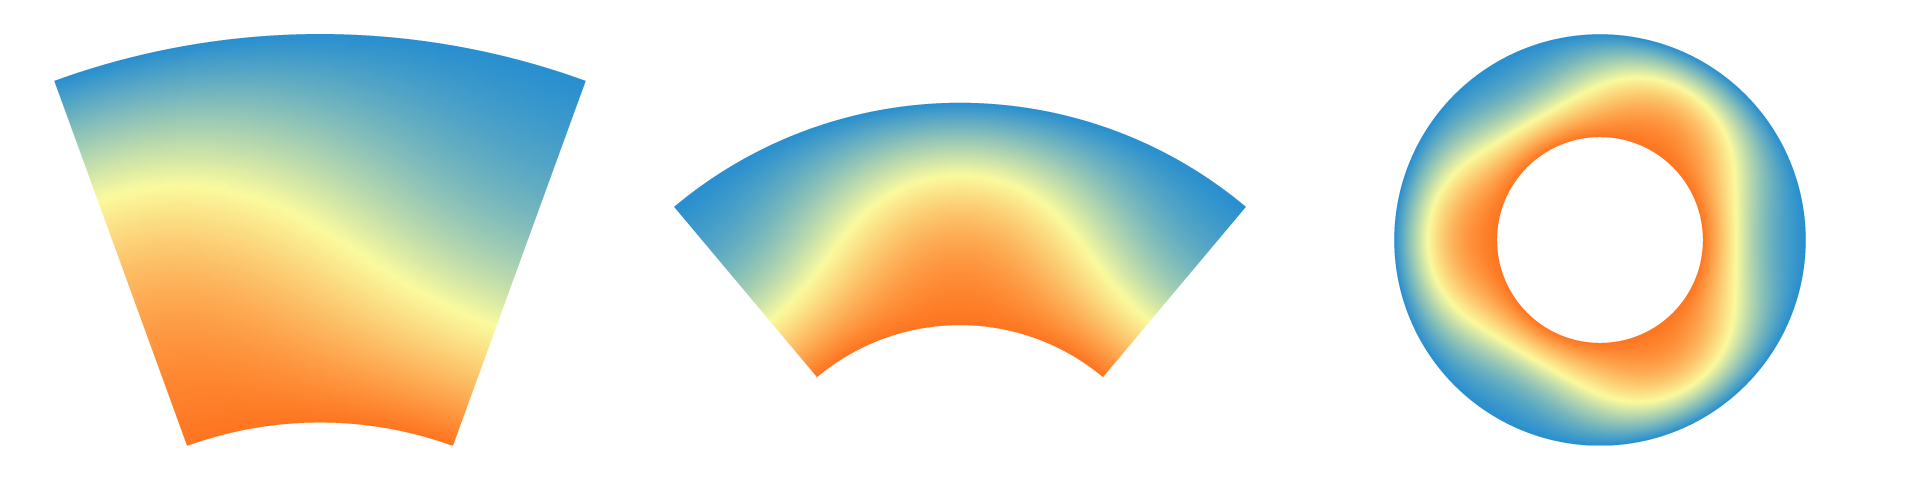

In [2]:
#| label: simplesinu
imop.hstack(*map(
    image.fromfile,
    reversed(glob(os.path.join(aliases.storagedir, 'simple_sinu_*.png')))
    ))

```{figure} #simplesinu
:name: simplesinu_fig

Illustration of the relationship between a wedge of an annulus and the full disc. We can tile the wedge across the whole disk by first mirroring it, then copying it. If we wish to avoid stretching or squeezing the original state to make it fit, we must ensure that $\Theta$ (angular extent of the wedge in radians) is a positive integer ratio of $\pi$. In this case, $\Theta$ goes from $\pi/3$ (left) to $2\pi/6$ (centre) to $2\pi$ (right: the full annulus).
```

In the same way that we built an artificial scale $r$ for the purpose of normalising the radial thickness, we can also build a scale $g$ for the width. This also gives us a chance to reverse the convention from anticlockwise (right-to-left) to clockwise (left-to-right), which is more familiar for Cartesian domains.

$$
g = \frac{\Theta - \theta}{\Theta}
$$

Defined this way, the coordinate pair $(g, h)$ reproduces in the annulus the $(x, y)$ coordinate system of a Cartesian unit square. This gives us a universal coordinate system for all cylindrical domains, regardless of curvature: allowing, for example, the 'splaying' of a Cartesian box model into an annular wedge, or the 'squaring up' of a wedge into a box.

When dealing with a Cartesian box geometry, one characteristic measure is the aspect ratio $A$, where for instance $A=1$ would denote a square box and $A=3$ a wide rectangle. If we wish to carry this measure into the cylindrical domain we need to choose a particular ring - a curve of constant depth - to be the characteristic angular length scale. The two most obvious candidates would be the outer and inner boundaries. However, it proves most convenient to take a different approach and instead draw an arc through the mid-depth, halfway (radially) between the outer and inner boundaries. The aspect ratio can then be defined as the length of this arc divided by the radial length. The mid-radius can be calculated from $f$:

$$
r_m \equiv \frac{r_{i} + r_{o}}{2} = \frac{1 + f}{2 \left( 1 - f \right)}
$$

Since the circumference of a complete circle is $ 2 \pi r$ (we would hope no citation is needed for that one), the angular length at depth $r_m$ can be calculated from $\Theta$:

$$
A = r_m \Theta
$$

Such a scheme leaves us with two competing claims for a 'natural' denominator of the angular coordinate - $\Theta$ and $r_m$. While authors have sometimes preferred to keep $\Theta$ and $r_m$ constant and allow $A$ to vary [@Jarvis1994-np], we have for the most part chosen to fix $A$ and $r_m$ with $\Theta$ as the free parameter, as in [@Jarvis1993-cb]. One of the virtues of this choice is that it preserves the $(g, h)$ coordinate system over varying $A$. This simplifies comparisons with plane-layer simulations, though potentially at the cost of producing planforms which could be unstable if scaled to the full annulus.

In the Cartesian case, when the height of the box is set to unit, the aspect ratio is not only equivalent to the box width: it is also equivalent to the box *area*. The virtue of defining cylindrical $A$ using the mid-depth is that this property is preserved even for extreme values of $f$. Parameterising a model in terms of area is particularly advantageous when dealing with system forcings, like internal heat, which scale with area.

While it is trivial to divide the domain in an angular sense (i.e. splitting the wedge into more wedges), dividing it in a radial sense requires a little more consideration. The proportion of the annulus lying below a particular height $h$ - which we shall call $D$ for 'disc' - is a function of the inner and mid-radii:

$$
D(h) = \frac{r^2 - {r_i}^2}{2 r_m}, \quad r = h + r_i
$$

As we have already established that the total area will always equal the aspect ratio $A$, the true area under any depth $h$ can then be given simply as $D \cdot A$.

Laying the datum for the aspect ratio through the mid-depth also has the benefit of providing a good reference scale for the angular length, which allows us to set aside $\theta$ and $\Theta$ altogether and deal with both radial and angular distances in like units. Let $s$ be the angular length at any given depth. We already know that $s_m = A$ by definition, but we can just as easily calculate $s$ for any value of $r$:

$$
s(r) = r \Theta = r \frac{A}{r_m} = r A \frac{2 \left( 1 - f \right)}{1 + f}
$$

At low values of $f$ (therefore high curvature), $s$ is strongly dependent on $r$, with the inner surface much shorter than the outer surface. Conversely, at values of $f$ approaching $1$, the dependence on $r$ disappears as the value of $r_o$ becomes indistinguishable from $r_i$ - in which case $s \approx A$ throughout the domain, as it does in a Cartesian box.

It will shortly prove convenient to non-dimensionalise $s$ as ${s^*} = s / A$, such that the dimensionless length through the mid-depth ${s^*} = 1$. We can then write ${s^*}$ very simply as a function of ${r^*}$ and the inner and outer lengths accordingly:

$$
{s^*} = 2 \frac{{r^*}}{1+f}
$$

$$
{s^*}_i = 2 \frac{f}{1+f}, \quad {s^*}_o = 2 \frac{1}{1+f}
$$

The length $s$ is, among other things, the factor by which an average measurement of some variable taken across a layer can be converted into a total value for that layer. It is vital to account for varying $s$ whenever comparing between different layers in a given system, or between equivalent layers in systems of differing $f$.